# RGM Copilot — Phase 1: Demand Forecasting

**Goal:** Forecast daily `units_sold` for every region × channel × SKU combination.

**Approach:** A single **global gradient-boosted model** (XGBoost) trained across all 160 series at once,
using lag/rolling features + calendar features + categorical encodings — rather than fitting 160
separate ARIMA/Prophet models per series.

This is a deliberate modeling choice, not a shortcut: global tree-based models are the standard
approach in modern large-scale retail/FMCG forecasting (this is essentially the winning approach
from the M5 Forecasting Competition) — they scale to many series, share information across
similar products/regions, and are far more practical in production than maintaining hundreds of
individual statistical models.

This notebook:
1. Loads the dataset from notebook 1
2. Engineers lag, rolling-window, and calendar features
3. Trains an XGBoost regressor with a proper time-based train/test split (no leakage)
4. Compares against a naive baseline (last week, same weekday)
5. Evaluates with MAE / RMSE / MAPE, with a feature importance and sample forecast plots
6. Saves the trained model for reuse in the GenAI function-calling layer (notebook 4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load data

In [2]:
df = pd.read_csv("../data/rgm_copilot_dataset.csv", parse_dates=["date"])
df = df.sort_values(["region", "channel", "sku", "date"]).reset_index(drop=True)
print(df.shape)
df.head()

(116800, 12)


,date,region,channel,sku,unit_price,on_promo,demand_units,units_sold,stockout_flag,on_hand_after,revenue,lead_time_days
0,2023-01-01,Alexandria & North Coast,E-Commerce,Cola Regular 330ml,11.919922,False,18,18.0,0,286.1,214.558598,3
1,2023-01-02,Alexandria & North Coast,E-Commerce,Cola Regular 330ml,11.891420,False,16,16.0,0,270.1,190.262715,3
2,2023-01-03,Alexandria & North Coast,E-Commerce,Cola Regular 330ml,11.991916,False,13,13.0,0,257.1,155.894904,3
3,2023-01-04,Alexandria & North Coast,E-Commerce,Cola Regular 330ml,12.051830,False,17,17.0,0,240.1,204.881112,3
4,2023-01-05,Alexandria & North Coast,E-Commerce,Cola Regular 330ml,12.241131,False,20,20.0,0,220.1,244.822617,3


## 2. Feature engineering

- **Calendar features**: day of week, month, weekend flag, cyclical day-of-year encoding (captures yearly seasonality smoothly)
- **Lag features**: sales 1, 7, 14, 28 days ago (per region/channel/SKU)
- **Rolling features**: 7/14/28-day rolling mean & std (shifted by 1 day to avoid leakage)
- **Known business inputs**: `on_promo` and `unit_price` — in a real RGM setting these are planned in advance, so it's valid to use them as forecasting inputs (not leakage, since promo calendars and pricing are set ahead of time)
- **Categorical encodings**: region, channel, sku

In [3]:
group_cols = ["region", "channel", "sku"]

df["dow"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["doy"] = df["date"].dt.dayofyear
df["is_weekend"] = (df["dow"] >= 4).astype(int)
df["doy_sin"] = np.sin(2 * np.pi * df["doy"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["doy"] / 365)

g = df.groupby(group_cols, group_keys=False)
for lag in [1, 7, 14, 28]:
    df[f"lag_{lag}"] = g["units_sold"].shift(lag)
for win in [7, 14, 28]:
    df[f"roll_mean_{win}"] = g["units_sold"].apply(lambda s: s.shift(1).rolling(win).mean())
    df[f"roll_std_{win}"] = g["units_sold"].apply(lambda s: s.shift(1).rolling(win).std())

for col in ["region", "channel", "sku"]:
    df[col + "_code"] = df[col].astype("category").cat.codes

df_model = df.dropna().reset_index(drop=True)
print("Rows after dropping warm-up NaNs (first 28 days per series):", df_model.shape)

Rows after dropping warm-up NaNs (first 28 days per series): (112320, 31)


## 3. Time-based train/test split

Critical for time series: we never randomly split rows. Train on everything before **2024-07-01**,
test on the final ~6 months. This simulates forecasting genuinely unseen future data.

In [4]:
feature_cols = [
    "dow", "month", "is_weekend", "doy_sin", "doy_cos",
    "lag_1", "lag_7", "lag_14", "lag_28",
    "roll_mean_7", "roll_mean_14", "roll_mean_28",
    "roll_std_7", "roll_std_14", "roll_std_28",
    "on_promo", "unit_price",
    "region_code", "channel_code", "sku_code",
]
target_col = "units_sold"

split_date = "2024-07-01"
train = df_model[df_model["date"] < split_date]
test = df_model[df_model["date"] >= split_date]

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print(f"Train: {train.shape[0]:,} rows  |  Test: {test.shape[0]:,} rows")
print(f"Train period: {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Test period:  {test['date'].min().date()} to {test['date'].max().date()}")

Train: 83,040 rows  |  Test: 29,280 rows
Train period: 2023-01-29 to 2024-06-30
Test period:  2024-07-01 to 2024-12-30


## 4. Baseline model

Before trusting any ML model, we need a baseline to prove it's actually adding value.
Baseline: **naive forecast = same weekday, last week** (`lag_7`). A surprisingly strong baseline
for retail data — if XGBoost can't beat this meaningfully, it's not worth the complexity.

In [5]:
baseline_pred = X_test["lag_7"]

mae_base = mean_absolute_error(y_test, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, baseline_pred))
mask = y_test > 0
mape_base = (np.abs(y_test[mask] - baseline_pred[mask]) / y_test[mask]).mean()

print(f"Baseline (lag_7)  ->  MAE: {mae_base:.2f}   RMSE: {rmse_base:.2f}   MAPE: {mape_base:.1%}")

Baseline (lag_7)  ->  MAE: 12.43   RMSE: 23.56   MAPE: 37.9%


## 5. Train XGBoost

In [6]:
model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
pred = model.predict(X_test)
pred = np.clip(pred, 0, None)  # sales can't be negative

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = (np.abs(y_test[mask] - pred[mask.values]) / y_test[mask]).mean()

print(f"XGBoost           ->  MAE: {mae:.2f}   RMSE: {rmse:.2f}   MAPE: {mape:.1%}")
print(f"\nImprovement over baseline: {(1 - mae/mae_base):.1%} lower MAE, {(1 - rmse/rmse_base):.1%} lower RMSE")

XGBoost           ->  MAE: 7.39   RMSE: 14.07   MAPE: 29.4%

Improvement over baseline: 40.6% lower MAE, 40.3% lower RMSE


## 6. Feature importance

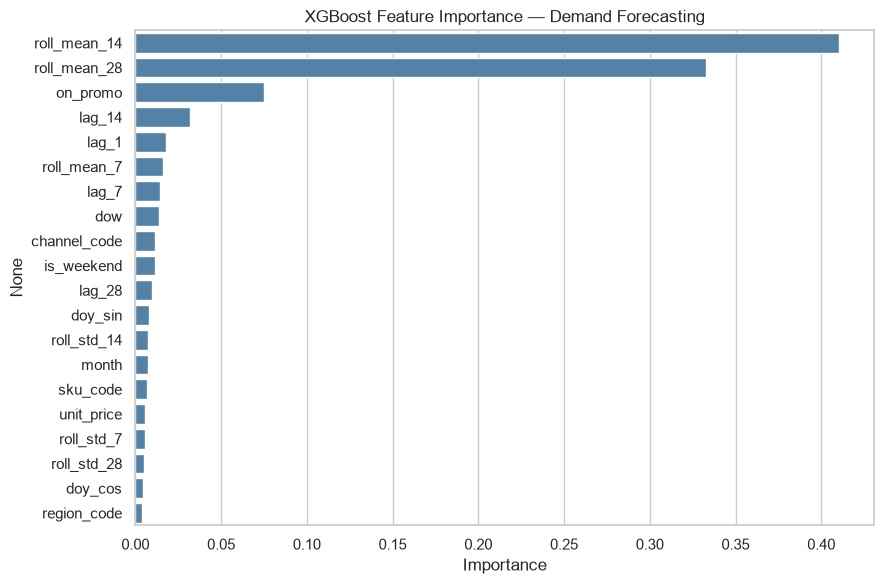

In [7]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=importance.values, y=importance.index, ax=ax, color="steelblue")
ax.set_title("XGBoost Feature Importance — Demand Forecasting")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Actual vs. predicted — sample series

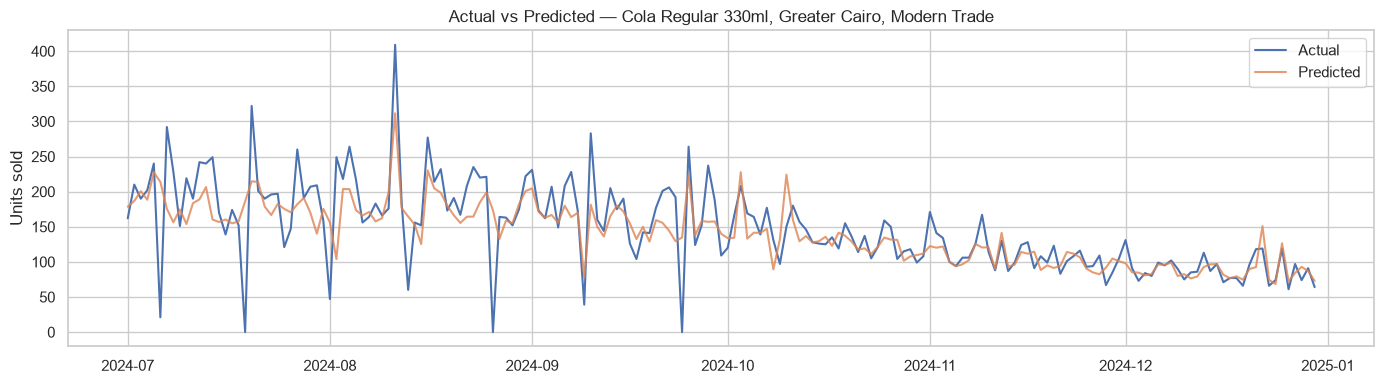

In [8]:
test_plot = test.copy()
test_plot["pred"] = pred

sample = test_plot[(test_plot["region"] == "Greater Cairo") &
                    (test_plot["channel"] == "Modern Trade") &
                    (test_plot["sku"] == "Cola Regular 330ml")].sort_values("date")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["date"], sample["units_sold"], label="Actual", linewidth=1.5)
ax.plot(sample["date"], sample["pred"], label="Predicted", linewidth=1.5, alpha=0.8)
ax.set_title("Actual vs Predicted — Cola Regular 330ml, Greater Cairo, Modern Trade")
ax.set_ylabel("Units sold")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Error breakdown by channel and SKU

Where is the model strongest/weakest? Useful to know which segments to trust more.

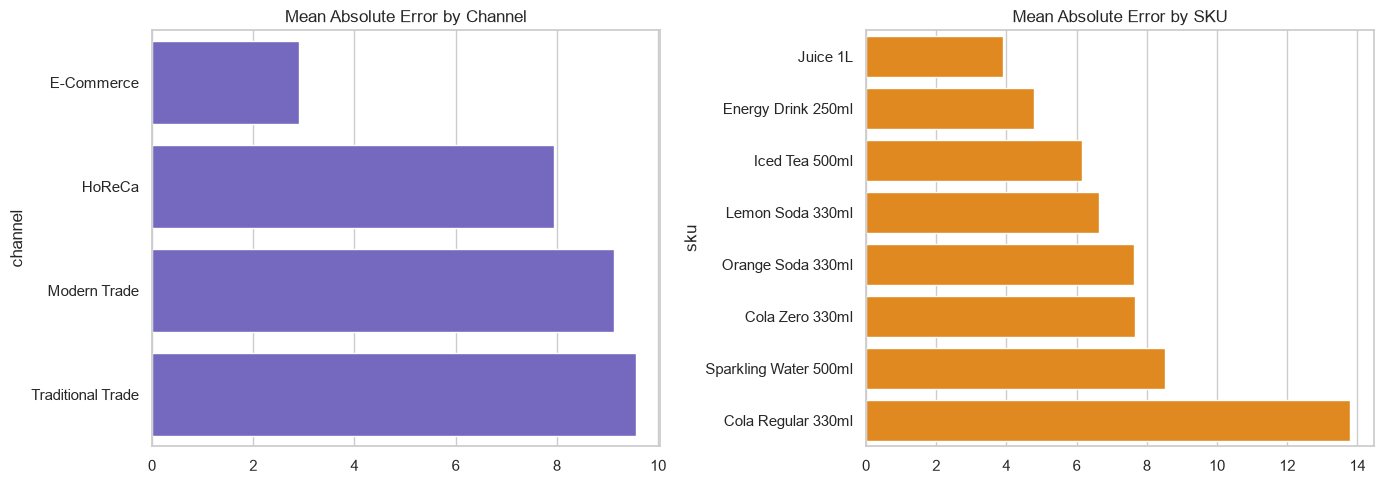

In [9]:
test_plot["abs_error"] = (test_plot["units_sold"] - test_plot["pred"]).abs()

by_channel = test_plot.groupby("channel")["abs_error"].mean().sort_values()
by_sku = test_plot.groupby("sku")["abs_error"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=by_channel.values, y=by_channel.index, ax=axes[0], color="slateblue")
axes[0].set_title("Mean Absolute Error by Channel")
sns.barplot(x=by_sku.values, y=by_sku.index, ax=axes[1], color="darkorange")
axes[1].set_title("Mean Absolute Error by SKU")
plt.tight_layout()
plt.show()

## 9. Save the model and a forecast lookup

This trained model + a saved test-period forecast table will be wired into the **GenAI function-calling layer**
in notebook 4, so the assistant can answer "what's the forecast for X" with real numbers.

In [10]:
joblib.dump(model, "../models/demand_forecast_model.pkl")
joblib.dump(feature_cols, "../models/demand_forecast_features.pkl")

forecast_lookup = test_plot[["date", "region", "channel", "sku", "units_sold", "pred"]].rename(
    columns={"units_sold": "actual", "pred": "forecast"}
)
forecast_lookup.to_csv("../models/forecast_lookup.csv", index=False)

print("Saved model files to ../models/")
print(forecast_lookup.head())

Saved model files to ../models/
          date                    region     channel                 sku  \
519 2024-07-01  Alexandria & North Coast  E-Commerce  Cola Regular 330ml   
520 2024-07-02  Alexandria & North Coast  E-Commerce  Cola Regular 330ml   
521 2024-07-03  Alexandria & North Coast  E-Commerce  Cola Regular 330ml   
522 2024-07-04  Alexandria & North Coast  E-Commerce  Cola Regular 330ml   
523 2024-07-05  Alexandria & North Coast  E-Commerce  Cola Regular 330ml   

     actual   forecast  
519    67.0  48.640934  
520    55.0  53.694977  
521    51.0  57.634457  
522    65.0  61.768681  
523     3.2  60.900669  
